This workbook is an adaptation from https://github.com/romainsacchi/BAFU2BW/blob/master/import%20BAFU%20LCA%20db.ipynb

In [ ]:
import bw2data, bw2io

In [2]:
bw2data.projects.set_current("bafu")

In [76]:
bw2io.create_default_biosphere3()

Applying strategy: normalize_units
Applying strategy: drop_unspecified_subcategories
Applying strategy: ensure_categories_are_tuples
Applied 3 strategies in 0.02 seconds


100%|████████████████████████████████████| 4709/4709 [00:00<00:00, 15738.58it/s]


10:13:23+0100 [info     ] Vacuuming database            
Created database: biosphere3


In [77]:
bw2data.databases

Databases dictionary with 1 object(s):
	biosphere3

In [78]:
fp = r"/Users/admin/Downloads/BAFU-2025 Version 2 - Package (ecoSpold1) 2026-03-09"

In [79]:
from pathlib import Path
from lxml import etree
import re

ECOSPOLD_DIR = Path(fp)  # root folder with .xml
DB_NAME = "bafu"

NAME_LOC_RE = re.compile(r"^(.*)\s+\{([^{}]+)\}\s*$")

def strip_location_from_name(name, current_location=None):
    """
    If name ends with ' {...}', strip this part and return (clean_name, location).
    Location from name overrides current_location if found.
    """
    if not name:
        return name, current_location
    m = NAME_LOC_RE.match(name)
    if not m:
        return name, current_location
    base, loc_str = m.groups()
    base = base.strip()
    loc = loc_str.strip()
    return base, (loc or current_location)

def get_first(elem, xpath):
    """Helper: return first match or None."""
    res = elem.xpath(xpath)
    return res[0] if res else None

def get_attr(elem, name, default=None):
    return elem.get(name) if elem is not None and elem.get(name) is not None else default


def build_reference_index(root_dir: Path):
    """
    First pass: for each dataset, find its main production exchange
    and build an index keyed by that exchange's 'number' (flow id).

    Returns: dict[flow_id] = {
        'activity_code': dataset_number,
        'name': clean_name,
        'reference product': clean_name,
        'location': location,
        'unit': unit,
    }
    """
    ref_index = {}

    for xml in root_dir.rglob("*.xml"):
        tree = etree.parse(str(xml))
        root = tree.getroot()

        dataset = get_first(root, '//*[local-name()="dataset"]')
        if dataset is None:
            continue

        PI = get_first(dataset, './/*[local-name()="processInformation"]')
        RF = get_first(PI, './/*[local-name()="referenceFunction"]') if PI is not None else None
        geo = get_first(PI, './/*[local-name()="geography"]') if PI is not None else None

        if RF is None:
            continue

        raw_name = get_attr(RF, "name", "") or ""
        unit = get_attr(RF, "unit", "")
        xml_location = get_attr(geo, "location", None) or "GLO"
        dataset_number = get_attr(dataset, "number", "")

        # Clean name and location
        clean_name, location = strip_location_from_name(raw_name, xml_location)

        # Find main production exchange (outputGroup == "0")
        flow_data = get_first(dataset, './/*[local-name()="flowData"]')
        prod_flow_id = None

        if flow_data is not None:
            for exc in flow_data.xpath('./*[local-name()="exchange"]'):
                og = get_first(exc, './*[local-name()="outputGroup"]')
                og_val = og.text.strip() if og is not None and og.text else None
                if og_val == "0":
                    prod_flow_id = get_attr(exc, "number", None)
                    if prod_flow_id:
                        break

        # Fallback: if we didn't find a production exchange number, use dataset number
        flow_id = prod_flow_id or dataset_number
        if not flow_id:
            continue

        ref_index[flow_id] = {
            "activity_code": dataset_number,
            "name": clean_name,
            "reference product": clean_name,
            "location": location,
            "unit": unit,
        }

    return ref_index

# Build the index once
ref_index = build_reference_index(ECOSPOLD_DIR)
print(f"Reference index contains {len(ref_index)} entries.")

Reference index contains 11747 entries.


In [80]:
import re
import html
import math
import numpy as np
from pathlib import Path
from stats_arrays.distributions import (
    LognormalUncertainty,
    NormalUncertainty,
    TriangularUncertainty,
    UniformUncertainty,
    UndefinedUncertainty,
)


def person_label(person_elem):
    """Return a compact 'Name (email)' label from a <person> element."""
    if person_elem is None:
        return None
    name = (get_attr(person_elem, "name", "") or "").strip()
    email = (get_attr(person_elem, "email", "") or "").strip()
    if name and email:
        return f"{name} ({email})"
    elif name:
        return name
    elif email:
        return email
    return None


def clean_comment(text: str) -> str:
    if not text:
        return ""

    # Decode HTML entities like &#10;
    t = html.unescape(text)

    # Drop trailing "UUID: ..." noise, if present
    t = re.sub(r"UUID:.*$", "", t, flags=re.S)

    # Normalise line breaks and remove empty lines
    lines = [ln.strip() for ln in t.replace("\r\n", "\n").split("\n")]
    lines = [ln for ln in lines if ln]  # drop completely empty lines

    return "\n".join(lines)


def add_uncertainty_fields_from_ecospold1(exc_xml, data: dict) -> dict:
    """
    Mutates & returns `data` by adding Brightway-style uncertainty fields
    from an ecospold1 <exchange> element.
    """

    # ecoSpold1 uncertaintyType (0..4)
    try:
        uncertainty = int(exc_xml.get("uncertaintyType", 0))
    except ValueError:
        uncertainty = 0

    def floatish(x):
        if x is None:
            return np.NaN
        try:
            return float(x.strip())
        except Exception:
            try:
                return float(x)
            except Exception:
                return np.NaN

    mean = floatish(exc_xml.get("meanValue"))
    min_ = floatish(exc_xml.get("minValue"))
    max_ = floatish(exc_xml.get("maxValue"))
    sigma95 = floatish(exc_xml.get("standardDeviation95"))

    # Some data has nonsense lognormal parameters -> treat as undefined
    if uncertainty == 1 and (sigma95 in (0, 1) or np.isnan(sigma95)):
        uncertainty = 0

    # ---------- LOGNORMAL ----------
    if uncertainty == 1:
        # Guard against mean <= 0 explicitly; lognormal not defined there
        if mean == 0 or np.isnan(mean):
            data.update(
                {
                    "uncertainty type": UndefinedUncertainty.id,
                    "amount": float(mean),
                    "loc": float(mean),
                }
            )
            return data

        # Normal lognormal case
        data.update(
            {
                "uncertainty type": LognormalUncertainty.id,  # ID 2
                "amount": float(mean),
                "loc": math.log(abs(mean)),
                "scale": math.log(math.sqrt(float(sigma95))),
                "negative": mean < 0,
            }
        )

        # Extra sanity check: bad scale -> fall back to undefined
        if np.isnan(data["scale"]):
            data["uncertainty type"] = UndefinedUncertainty.id
            data["loc"] = data["amount"]
            data.pop("scale", None)

        return data

    # ---------- NORMAL ----------
    if uncertainty == 2:
        data.update(
            {
                "uncertainty type": NormalUncertainty.id,  # ID 3
                "amount": float(mean),
                "loc": float(mean),
                "scale": float(sigma95) / 2.0,
            }
        )
        return data

    # ---------- TRIANGULAR ----------
    if uncertainty == 3:
        data.update(
            {
                "uncertainty type": TriangularUncertainty.id,  # ID 5
                "minimum": float(min_),
                "maximum": float(max_),
            }
        )
        most_likely = floatish(exc_xml.get("mostLikelyValue"))
        if not np.isnan(most_likely):
            data["amount"] = data["loc"] = most_likely
        else:
            data["amount"] = data["loc"] = float(mean)
        return data

    # ---------- UNIFORM ----------
    if uncertainty == 4:
        data.update(
            {
                "uncertainty type": UniformUncertainty.id,  # ID 4
                "amount": float(mean),
                "minimum": float(min_),
                "maximum": float(max_),
            }
        )
        return data

    # ---------- UNDEFINED / NO UNCERTAINTY ----------
    data.update(
        {
            "uncertainty type": UndefinedUncertainty.id,  # ID 0
            "amount": float(mean),
            "loc": float(mean),
        }
    )
    return data

UNITS_MAP = {
    'kg': 'kilogram',
    'tkm': 'ton kilometer',
    'p': 'unit',
    'kWh': 'kilowatt hour',
    'MJ': 'megajoule',
    'm2': 'square meter',
    'm': 'meter',
    'Nm3': 'cubic meter',
    'km': 'kilometer',
    'personkm': 'person-kilometer',
    'my': 'meter-year',
    'unit': 'unit',
    'm3': 'cubic meter',
    'm2a': 'square meter-year',
    'kmy': 'kilometer-year',
    'a': 'year',
    'm3y': 'cubic meter-year',
    'kBq': 'kilo Becquerel',
    'ha': 'hectare',
    'Bq': 'Becquerel',
    'hr': 'hour'
}

CATS_MAP = {
    ('emissions to air', 'unspecified'): ('air',),
    ('emissions to air', 'high. pop.'): ('air', 'urban air close to ground'),
    ('emissions to air', 'low. pop.'): ('air', 'non-urban air or from high stacks'),
    ('emissions to air', 'stratosphere + troposphere'): ('air', 'lower stratosphere + upper troposphere'),
    ('emissions to air', 'low. pop., long-term'): ('air', 'low population density, long-term'),
    ('emissions to air', 'indoor'): ('air', 'urban air close to ground'),
    
    ('emissions to soil', 'unspecified'): ('soil',),
    ('emissions to soil', 'forestry'): ('soil', 'forestry'),
    ('emissions to soil', 'agricultural'): ('soil', 'agricultural'),
    ('emissions to soil', 'industrial'): ('soil', 'industrial'),
    
    ('emissions to water', 'ocean'): ('water', 'ocean'),
    ('emissions to water', 'river'): ('water', 'surface water'),
    ('emissions to water', 'unspecified'): ('water',),
    ('emissions to water', 'groundwater, long-term'): ('water', 'ground-, long-term'),
    ('emissions to water', 'groundwater'): ('water', 'ground-'),
    ('emissions to water', 'lake'): ('water', 'surface water'),
    ('emissions to water', 'river, long-term'): ('water', 'surface water'),
    ('emissions to water', 'fossilwater'): ('water', 'fossil well'),
    
    ('economic issues', 'unspecified'): ('economic', 'primary production factor'),

    ('resources', 'in ground'): ('natural resource', 'in ground'),
    ('resources', 'land'): ('natural resource', 'land'),
    ('resources', 'in water'): ('natural resource', 'in water'),
    ('resources', 'in air'): ('natural resource', 'in air'),
    ('resources', 'biotic'): ('natural resource', 'biotic'),
}

def parse_ecospold_file(xml_path: Path, db_name: str, ref_index: dict):
    """Parse a single ecoSpold1 file into a Brightway-like dict, using ref_index."""
    tree = etree.parse(str(xml_path))
    root = tree.getroot()

    dataset = get_first(root, '//*[local-name()="dataset"]')
    if dataset is None:
        return None

    PI = get_first(dataset, './/*[local-name()="processInformation"]')
    RF = get_first(PI, './/*[local-name()="referenceFunction"]') if PI is not None else None
    geo = get_first(PI, './/*[local-name()="geography"]') if PI is not None else None
    TP = get_first(PI, './/*[local-name()="timePeriod"]') if PI is not None else None

    if RF is None:
        return None

    # Basic fields
    raw_name = get_attr(RF, "name", "") or ""
    unit = UNITS_MAP.get(get_attr(RF, "unit", ""))
    xml_location = get_attr(geo, "location", None) or "GLO"
    dataset_number = get_attr(dataset, "number", "")

    # Clean activity name and location (strip trailing {LOC})
    name, location = strip_location_from_name(raw_name, xml_location)
    ref_product = name

    # Build comment from various ecoSpold1 fields, then clean it
        # --- Build enriched comment from RF + timePeriod + metaInformation ---

    rf_comment = get_attr(RF, "generalComment", "") or ""

    # Time period: text + explicit start/end dates if present
    tp_text = get_attr(TP, "text", "") or ""
    tp_start_elem = get_first(TP, './/*[local-name()="startDate"]') if TP is not None else None
    tp_end_elem = get_first(TP, './/*[local-name()="endDate"]') if TP is not None else None
    tp_start = (tp_start_elem.text or "").strip() if tp_start_elem is not None and tp_start_elem.text else ""
    tp_end = (tp_end_elem.text or "").strip() if tp_end_elem is not None and tp_end_elem.text else ""

    time_lines = []
    if tp_text:
        time_lines.append(f"Time period: {tp_text}")
    if tp_start or tp_end:
        if tp_start and tp_end:
            time_lines.append(f"Time period (data): {tp_start} – {tp_end}")
        elif tp_start:
            time_lines.append(f"Time period (data): from {tp_start}")
        elif tp_end:
            time_lines.append(f"Time period (data): until {tp_end}")

    # Geography line: location + textual description if any
    geo_text = get_attr(geo, "text", "") or ""
    geo_lines = []
    if xml_location or geo_text:
        if geo_text:
            geo_lines.append(f"Geography: {xml_location} – {geo_text}")
        else:
            geo_lines.append(f"Geography: {xml_location}")

    # Technology description
    tech = get_first(PI, './/*[local-name()="technology"]') if PI is not None else None
    tech_text = get_attr(tech, "text", "") or ""
    tech_lines = []
    if tech_text:
        tech_lines.append(f"Technology: {tech_text}")

    # metaInformation (administrative + modelling & validation)
    MI = get_first(dataset, './/*[local-name()="metaInformation"]')
    AI = get_first(MI, './/*[local-name()="administrativeInformation"]') if MI is not None else None
    MV = get_first(MI, './/*[local-name()="modellingAndValidation"]') if MI is not None else None

    meta_lines = []

    # --- Representativeness & production volume ---
    rep = get_first(MV, './/*[local-name()="representativeness"]') if MV is not None else None
    if rep is not None:
        rep_parts = []

        # some schemas use e.g. "productionVolume", others "productionVolumeText"
        prod_vol = get_attr(rep, "productionVolume", "") or ""
        sampling = get_attr(rep, "samplingProcedure", "") or ""
        extrap = get_attr(rep, "extrapolations", "") or ""
        unc_adj = get_attr(rep, "uncertaintyAdjustments", "") or ""

        if prod_vol and prod_vol.lower() != "na":
            rep_parts.append(f"Production volume: {prod_vol}")
        if sampling and sampling.lower() != "<null>":
            rep_parts.append(f"Sampling: {sampling}")
        if extrap and extrap.lower() != "<null>":
            rep_parts.append(f"Extrapolations: {extrap}")
        if unc_adj and unc_adj.lower() != "none":
            rep_parts.append(f"Uncertainty adjustments: {unc_adj}")

        if rep_parts:
            meta_lines.append("Representativeness: " + "; ".join(rep_parts))

    # --- People: build index of persons in this dataset ---
    persons = {}
    if AI is not None:
        for p in AI.xpath('.//*[local-name()="person"]'):
            num = get_attr(p, "number", None)
            if num:
                persons[num] = p

        # Data entry person
        de = get_first(AI, './/*[local-name()="dataEntryBy"]')
        de_num = get_attr(de, "person", None) if de is not None else None
        de_label = person_label(persons.get(de_num))
        if de_label:
            meta_lines.append(f"Data entry: {de_label}")

        # Data generator
        dgp = get_first(AI, './/*[local-name()="dataGeneratorAndPublication"]')
        dgp_num = get_attr(dgp, "person", None) if dgp is not None else None
        dgp_label = person_label(persons.get(dgp_num))
        if dgp_label:
            meta_lines.append(f"Data generator: {dgp_label}")

    # --- Validation info ---
    if MV is not None:
        val = get_first(MV, './/*[local-name()="validation"]')
        if val is not None:
            details = get_attr(val, "proofReadingDetails", "") or ""
            validator_num = get_attr(val, "proofReadingValidator", None)
            validator_label = person_label(persons.get(validator_num)) if validator_num else None

            if validator_label:
                meta_lines.append(f"Proof-reading validator: {validator_label}")
            if details:
                meta_lines.append(f"Validation details: {details}")

    # --- Source / publication info ---
    if MV is not None:
        src = get_first(MV, './/*[local-name()="source"]')
        if src is not None:
            first_author = get_attr(src, "firstAuthor", "") or ""
            add_authors = get_attr(src, "additionalAuthors", "") or ""
            year = get_attr(src, "year", "") or ""
            title = get_attr(src, "title", "") or ""
            publisher = get_attr(src, "publisher", "") or ""
            place = get_attr(src, "placeOfPublications", "") or ""
            volume = get_attr(src, "volumeNo", "") or ""

            src_parts = []
            if first_author:
                src_parts.append(first_author)
            if add_authors:
                # compress "Frischknecht R., Stolz P." instead of listing everything verbosely
                src_parts.append(add_authors)
            if year:
                src_parts.append(f"({year})")
            if title:
                src_parts.append(title)
            if publisher or place or volume:
                pub_bits = ", ".join(
                    [x for x in [publisher, place, f"vol. {volume}" if volume else ""] if x]
                )
                if pub_bits:
                    src_parts.append(pub_bits)

            if src_parts:
                meta_lines.append("Source: " + " ".join(src_parts))

    # --- Combine everything and clean it ---
    comment_sections = []

    if rf_comment:
        comment_sections.append(rf_comment)

    comment_sections.extend(time_lines)
    comment_sections.extend(geo_lines)
    comment_sections.extend(tech_lines)
    comment_sections.extend(meta_lines)

    comment = clean_comment("\n".join(cs for cs in comment_sections if cs))


    # Simple classifications
    category = get_attr(RF, "category", None)
    subcategory = get_attr(RF, "subCategory", None)
    classifications = []
    if category or subcategory:
        classifications.append(
            ("EcoSpold01Categories", f"{category or ''}/{subcategory or ''}")
        )

    # Exchanges
    flow_data = get_first(dataset, './/*[local-name()="flowData"]')
    exchanges = []

    if flow_data is not None:
        for exc in flow_data.xpath('./*[local-name()="exchange"]'):
            # We still require a numeric meanValue; skip if missing
            mean_value = get_attr(exc, "meanValue", None)
            if mean_value is None:
                continue

            raw_ex_name = get_attr(exc, "name", "") or ""
            ex_unit = UNITS_MAP.get(get_attr(exc, "unit", ""))
            ex_cat = get_attr(exc, "category", "")
            ex_subcat = get_attr(exc, "subCategory", "")
            ex_loc_xml = get_attr(exc, "location", None)

            # Strip location from exchange name
            ex_name, ex_loc_from_name = strip_location_from_name(raw_ex_name, ex_loc_xml)
            ex_loc = ex_loc_from_name

            og = get_first(exc, './*[local-name()="outputGroup"]')
            ig = get_first(exc, './*[local-name()="inputGroup"]')
            og_val = og.text.strip() if og is not None and og.text else None
            ig_val = ig.text.strip() if ig is not None and ig.text else None

            ex_cat_lower = (ex_cat or "").lower()
            ex_subcat_lower = (ex_subcat or "").lower()
            
            # Heuristics for biosphere categories
            is_biosphere_category = (
                ex_cat_lower.startswith("emissions to ")
                or ex_cat_lower.startswith("emission to ")
                or ex_cat_lower in {"emissions", "emission"}
                or "resource" in ex_cat_lower
                or (ex_cat, ex_subcat) in CATS_MAP
            )
            
            # Lithium case: category 'resources', subcategory 'in ground'
            # will satisfy "resource" in ex_cat_lower and be biosphere.
            
            if og_val == "0":
                ex_type = "production"
            elif is_biosphere_category:
                ex_type = "biosphere"
            elif ig_val is not None:
                ex_type = "technosphere"
            else:
                # Fallback: if we have no input group and no explicit biosphere category,
                # treat it as biosphere (this will catch odd emissions that lack inputGroup)
                ex_type = "biosphere"


            exc_dict = {
                "name": ex_name,
                "unit": ex_unit,
                "type": ex_type,
                "categories": CATS_MAP.get((ex_cat, ex_subcat), (ex_cat, ex_subcat)),
            }

            if ex_loc:
                exc_dict["location"] = ex_loc

            # Optional per-exchange comment (also cleaned a bit)
            ex_comment = exc.get("generalComment")
            if ex_comment:
                exc_dict["comment"] = clean_comment(ex_comment)

            ex_number = get_attr(exc, "number", None)
            if ex_number:
                exc_dict["flow"] = ex_number

                # Inject reference product from the producer, if known
                if ex_type in ("technosphere", "production"):
                    ref_info = ref_index.get(ex_number)
                    if ref_info is not None:
                        exc_dict["reference product"] = ref_info["reference product"]
                        if "location" not in exc_dict or not exc_dict["location"]:
                            exc_dict["location"] = ref_info["location"]

            # Add Brightway-style uncertainty parameters
            add_uncertainty_fields_from_ecospold1(exc, exc_dict)

            exchanges.append(exc_dict)

    data = {
        "database": db_name,
        "code": dataset_number,
        "name": name,
        "reference product": ref_product,
        "location": location,
        "unit": unit,
        "comment": comment,
        "classifications": classifications,
        "exchanges": exchanges,
        "filename": xml_path.name,
        "type": "process",
    }

    return data


# Second pass: build all dataset dicts
all_data = []

for xml in ECOSPOLD_DIR.rglob("*.xml"):
    dct = parse_ecospold_file(xml, DB_NAME, ref_index)
    if dct is not None:
        all_data.append(dct)

print(f"Built {len(all_data)} dataset dictionaries.")


Built 11747 dataset dictionaries.


In [81]:
import csv
import ast
from pathlib import Path

CSV_PATH = Path("elementary_flows_mapping.csv")


def parse_category(cat_str):
    cat_str = (cat_str or "").strip()
    if not cat_str:
        return None
    return tuple(ast.literal_eval(cat_str))

mapping = {}

with open(CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter=",")

    # Fix BOM in header if present
    if reader.fieldnames:
        reader.fieldnames = [fn.lstrip("\ufeff") for fn in reader.fieldnames]

    for row in reader:
        bafu_name = row["BAFU name"].strip()
        bafu_cat = parse_category(row["BAFU category"])

        key = (bafu_name, bafu_cat)

        mapping[key] = {
            "ecoinvent_name": (row.get("Ecoinvent name") or "").strip() or None,
            "ecoinvent_category": parse_category(row.get("Ecoinvent category")),
        }

print(f"{len(mapping)} entries loaded.")

1004 entries loaded.


In [136]:

n_biosphere = 0
n_remapped = 0

for dataset in all_data:
    for exchange in dataset.get("exchanges", []):
        if exchange.get("type") != "biosphere":
            continue

        n_biosphere += 1

        # Preserve source-flow fields before remapping.
        # setdefault protects the original values if this cell is rerun.
        exchange.setdefault("original_name", exchange.get("name"))
        exchange.setdefault("original_categories", exchange.get("categories"))
        exchange.setdefault("original_unit", exchange.get("unit"))

        key = (
            exchange["original_name"],
            exchange["original_categories"],
        )

        mapped = mapping.get(key)
        if mapped is None:
            continue

        new_name = mapped.get("ecoinvent_name")
        new_categories = mapped.get("ecoinvent_category")

        if new_name:
            exchange["name"] = new_name

        if new_categories:
            exchange["categories"] = new_categories

        n_remapped += 1

print(f"Biosphere exchanges checked: {n_biosphere:,}")
print(f"Biosphere exchanges remapped: {n_remapped:,}")

Biosphere exchanges checked: 293,179
Biosphere exchanges remapped: 6,714


In [159]:
importer = bw2io.importers.base_lci.LCIImporter(db_name="bafu")

In [160]:
importer.data = all_data

In [161]:
importer.apply_strategies()

Applying strategy: normalize_units
Applying strategy: drop_unspecified_subcategories
Applying strategy: assign_only_product_as_production
Applying strategy: strip_biosphere_exc_locations
Applied 4 strategies in 1.22 seconds


In [163]:
importer.match_database(fields=["name", "reference product", "location"])
importer.match_database("biosphere3", fields=["name", "categories"])

Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields


In [164]:
importer.statistics()

Graph statistics for `bafu` importer:
11747 graph nodes:
	process: 11747
417709 graph edges:
	biosphere: 293179
	technosphere: 112783
	production: 11747
408975 edges to the following databases:
	biosphere3: 284445
	bafu: 124530
246 unique unlinked edges (8734 total):
	biosphere: 246




(11747, 417709, 8734, 0)

In [166]:
# Lets see the unlinked
unlinked_biosphere = pd.DataFrame([
    {
        "brightway_name": exchange.get("name"),
        "brightway_categories": tuple(exchange.get("categories") or ()),
        "brightway_unit": exchange.get("unit"),
        "source_name": exchange.get("original_name"),
        "source_categories": tuple(exchange.get("original_categories") or ()),
        "source_unit": exchange.get("original_unit"),
    }
    for exchange in importer.unlinked
    if exchange.get("type") == "biosphere"
])

print(f"Unique unresolved biosphere flow keys: {len(unlinked_biosphere):,}")

display(
    unlinked_biosphere
    .sort_values(["brightway_name", "brightway_categories", "brightway_unit"])
    .reset_index(drop=True)
    .head(20)
)

Unique unresolved biosphere flow keys: 246


,brightway_name,brightway_categories,brightway_unit,source_name,source_categories,source_unit
0,"('air', 'non-urban air or from high stacks')","(air,)",kilogram,"('air', 'non-urban air or from high stacks')","(air,)",kilogram
1,(Aminooxy)(hydroxy)sulfane dioxide,"(soil, industrial)",kilogram,(Aminooxy)(hydroxy)sulfane dioxide,"(soil, industrial)",kilogram
2,1-Methyl-2-pyrrolidinone,"(air,)",kilogram,1-Methyl-2-pyrrolidinone,"(air,)",kilogram
3,"2,2,4-Trimethyl pentane","(water, surface water)",kilogram,"2,2,4-Trimethyl pentane","(water, surface water)",kilogram
4,2-Methyl-4-chlorophenoxyacetic acid,"(soil, agricultural)",kilogram,2-Methyl-4-chlorophenoxyacetic acid,"(soil, agricultural)",kilogram
5,"4,4'-Biphenol","(air,)",kilogram,"4,4'-Biphenol","(air,)",kilogram
6,Acetochlor,"(air,)",kilogram,Acetochlor,"(air,)",kilogram
7,Acetochlor,"(water, surface water)",kilogram,Acetochlor,"(water, surface water)",kilogram
8,"Acetylene, dichloro-","(air,)",kilogram,"Acetylene, dichloro-","(air,)",kilogram
9,"Acetylene, dichloro-","(air, urban air close to ground)",kilogram,"Acetylene, dichloro-","(air, urban air close to ground)",kilogram


Instead of dropping unliked with importer.drop_unlinked(i_am_reckless=True). We can analyse the unlinked here. 

Cell 1: load priority file and create matching keys- note the priority file was generated using jsonld. So, we need to do some little normalisation. 

In [145]:
PRIORITY_FILE ="/Users/admin/Desktop/Database reductions/BAFU/Full database/priority_out/lcia_flow_priority.csv"


In [167]:
import pandas as pd

ETA_COL = "eta_0_99"
LOSS_COL = "loss_max_0_99"


def clean_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()


def normalise_unit(x):
    x = clean_text(x)

    unit_map = {
        "kilogram": "kg",
        "cubic meter": "m3",
        "square meter": "m2",
        "square meter-year": "m2*a",
        "kilometer": "km",
        "person-kilometer": "p*km",
        "ton kilometer": "t*km",
    }

    return unit_map.get(x, x)


def normalise_compartment(x):
    x = clean_text(x)

    compartment_map = {
        "air": "emission to air",
        "emission to air": "emission to air",
        "emissions to air": "emission to air",

        "water": "emission to water",
        "emission to water": "emission to water",
        "emissions to water": "emission to water",

        "soil": "emission to soil",
        "emission to soil": "emission to soil",
        "emissions to soil": "emission to soil",

        "resources": "resource",
        "resource": "resource",
        "natural resource": "resource",

        "non material emissions": "immaterial emission",
        "immaterial emission": "immaterial emission",

        "economic": "economic",
    }

    return compartment_map.get(x, x)


def normalise_subcompartment(x):
    x = clean_text(x)
    return x if x else "unspecified"


def category_part(categories, index):
    if not isinstance(categories, (tuple, list)):
        return ""
    if len(categories) <= index:
        return ""
    return categories[index]


def context_key(name, compartment, subcompartment, unit):
    return (
        clean_text(name)
        + " | " + normalise_compartment(compartment)
        + " | " + normalise_subcompartment(subcompartment)
        + " | " + normalise_unit(unit)
    )


def name_unit_key(name, unit):
    return clean_text(name) + " | " + normalise_unit(unit)


priority = pd.read_csv(PRIORITY_FILE)

priority["context_key"] = priority.apply(
    lambda r: context_key(
        r["flow_name"],
        r["compartment"],
        r["subcompartment"],
        r["reference_unit"],
    ),
    axis=1,
)

priority["name_unit_key"] = priority.apply(
    lambda r: name_unit_key(r["flow_name"], r["reference_unit"]),
    axis=1,
)

print(f"Priority-file rows: {len(priority):,}")
print(f"Unique context keys: {priority['context_key'].nunique():,}")
print(f"Unique name-unit keys: {priority['name_unit_key'].nunique():,}")

Priority-file rows: 2,465
Unique context keys: 2,454
Unique name-unit keys: 1,314


Cell 2: match unresolved Brightway flows to priority rows

In [168]:
# Build context keys for unresolved Brightway biosphere flows.
# Context key = source name + compartment + subcompartment + unit.
# This avoids name-only or name-unit matching.

unlinked = unlinked_biosphere.copy()

unlinked["source_compartment"] = unlinked["source_categories"].map(
    lambda x: category_part(x, 0)
)

unlinked["source_subcompartment"] = unlinked["source_categories"].map(
    lambda x: category_part(x, 1)
)

unlinked["context_key"] = unlinked.apply(
    lambda r: context_key(
        r["source_name"],
        r["source_compartment"],
        r["source_subcompartment"],
        r["source_unit"],
    ),
    axis=1,
)


# Keep priority fields needed for interpretation.
# Witness columns are included if present in the priority file.
witness_cols = [
    col for col in priority.columns
    if "witness" in col.lower()
]

priority_cols = [
    "flow_id",
    "flow_name",
    "compartment",
    "subcompartment",
    "reference_unit",
    ETA_COL,
    LOSS_COL,
] + witness_cols


# Only accept priority-file keys that identify exactly one row.
# Ambiguous context keys are left unclassified.
context_counts = priority["context_key"].value_counts()

priority_unique = priority[
    priority["context_key"].map(context_counts).eq(1)
].copy()

ambiguous_context_keys = set(
    context_counts[context_counts > 1].index
)


# Conservative context-only join.
matched = unlinked.merge(
    priority_unique[["context_key"] + priority_cols],
    on="context_key",
    how="left",
)

matched["match_status"] = "context_match"

matched.loc[
    matched[ETA_COL].isna(),
    "match_status"
] = "not_found"

matched.loc[
    matched["context_key"].isin(ambiguous_context_keys),
    "match_status"
] = "ambiguous_context_key"


def priority_class(eta):
    if pd.isna(eta):
        return "not_evaluated"
    if eta == 0:
        return "eta = 0"
    if eta < 0.1:
        return "0 < eta < 0.1"
    if eta < 0.5:
        return "0.1 <= eta < 0.5"
    if eta < 0.9:
        return "0.5 <= eta < 0.9"
    if eta < 0.99:
        return "0.9 <= eta < 0.99"
    return "eta = 0.99"


matched["priority_class"] = matched[ETA_COL].map(priority_class)


summary = (
    matched
    .groupby(["match_status", "priority_class"], dropna=False)
    .size()
    .reset_index(name="n_flows")
)

display(summary)

display(
    matched[
        matched["match_status"].eq("context_match")
    ]
    .sort_values([ETA_COL, LOSS_COL], ascending=False)
    .reset_index(drop=True)
    .head(30)
)

matched.to_csv(
    "bafu_unlinked_biosphere_priority_context_join.csv",
    index=False,
)

summary.to_csv(
    "bafu_unlinked_biosphere_priority_context_summary.csv",
    index=False,
)

,match_status,priority_class,n_flows
0,context_match,0 < eta < 0.1,14
1,context_match,0.1 <= eta < 0.5,10
2,context_match,0.5 <= eta < 0.9,5
3,context_match,0.9 <= eta < 0.99,3
4,context_match,eta = 0,73
5,context_match,eta = 0.99,24
6,not_found,not_evaluated,117


,brightway_name,brightway_categories,brightway_unit,source_name,source_categories,source_unit,source_compartment,source_subcompartment,context_key,flow_id,flow_name,compartment,subcompartment,reference_unit,eta_0_99,loss_max_0_99,eta_0_95_witness,eta_0_99_witness,match_status,priority_class
0,"Noise, road, lorry, average","(non material emissions,)",kilometer,"Noise, road, lorry, average","(non material emissions, unspecified)",kilometer,non material emissions,unspecified,"noise, road, lorry, average | immaterial emiss...",307a17c2-6434-3cf4-9527-2bd1c2288f3e,"Noise, road, lorry, average",Immaterial emission,unspecified,km,0.990000,1.000000,"Transport, freight, lorry, compressed gas, 100...","Transport, freight, lorry, compressed gas, 100...",context_match,eta = 0.99
1,"Noise, road, passenger car, average","(non material emissions,)",kilometer,"Noise, road, passenger car, average","(non material emissions, unspecified)",kilometer,non material emissions,unspecified,"noise, road, passenger car, average | immateri...",6fa59153-aeea-33db-89a5-dc8f2672908b,"Noise, road, passenger car, average",Immaterial emission,unspecified,km,0.990000,1.000000,"Transport, passenger car, gasoline hybrid, Lar...","Transport, passenger car, gasoline hybrid, Lar...",context_match,eta = 0.99
2,"Noise, aircraft, passenger","(non material emissions,)",person-kilometer,"Noise, aircraft, passenger","(non material emissions, unspecified)",person-kilometer,non material emissions,unspecified,"noise, aircraft, passenger | immaterial emissi...",e0a1cf01-4d3a-3333-bb55-33dafa357fd3,"Noise, aircraft, passenger",Immaterial emission,unspecified,p*km,0.990000,1.000000,"Transport, passenger, helicopter, single-engin...","Transport, passenger, helicopter, single-engin...",context_match,eta = 0.99
3,"Transformation, from unspecified, used","(resources,)",square meter,"Transformation, from unspecified, used","(resources, unspecified)",square meter,resources,unspecified,"transformation, from unspecified, used | resou...",85a087a2-6217-3cc1-9f2f-1cc9dccf6f9d,"Transformation, from unspecified, used",Resource,unspecified,m2,0.990000,1.000000,Gluing mill {CH} | Land use | -,Gluing mill {CH} | Land use | -,context_match,eta = 0.99
4,Waste water/m3,"(water,)",cubic meter,Waste water/m3,"(water,)",cubic meter,water,,waste water/m3 | emission to water | unspecifi...,e0065ac9-4578-3e8d-9338-fd99a299ae46,Waste water/m3,Emission to water,unspecified,m3,0.990000,1.000000,"Glider, for electric scooter {RER} | Water int...","Glider, for electric scooter {RER} | Water int...",context_match,eta = 0.99
5,"Acetylene, dichloro-","(air,)",kilogram,"Acetylene, dichloro-","(air,)",kilogram,air,,"acetylene, dichloro- | emission to air | unspe...",6277bb68-8dde-36f6-8d89-f588c0720ccc,"Acetylene, dichloro-",Emission to air,unspecified,kg,0.990000,1.000000,"Light fuel oil, burned in industrial furnace 1...","Light fuel oil, burned in industrial furnace 1...",context_match,eta = 0.99
6,"Occupation, industrial area, built up","(resources,)",square meter-year,"Occupation, industrial area, built up","(resources, unspecified)",square meter-year,resources,unspecified,"occupation, industrial area, built up | resour...",cf39ec61-e779-4614-97b7-ec622556040d,"Occupation, industrial area, built up",Resource,unspecified,m2*a,0.990000,1.000000,"Electricity, hydropower, at pumped storage pow...","Electricity, hydropower, at pumped storage pow...",context_match,eta = 0.99
7,"Water, process, unspecified natural origin/kg","(resources,)",kilogram,"Water, process, unspecified natural origin/kg","(resources, unspecified)",kilogram,resources,unspecified,"water, process, unspecified natural origin/kg ...",d2fc8c70-6510-3f1f-933a-39f3a263c609,"Water, process, unspecified natural origin/kg",Resource,unspecified,kg,0.990000,1.000000,"Three- and five-layered board, at plant {RER} ...","Three- and five-layered board, at plant {RER} ...",context_match,eta = 0.99
8,"Occupation, annual crop, non-irrigated, intensive","(reso

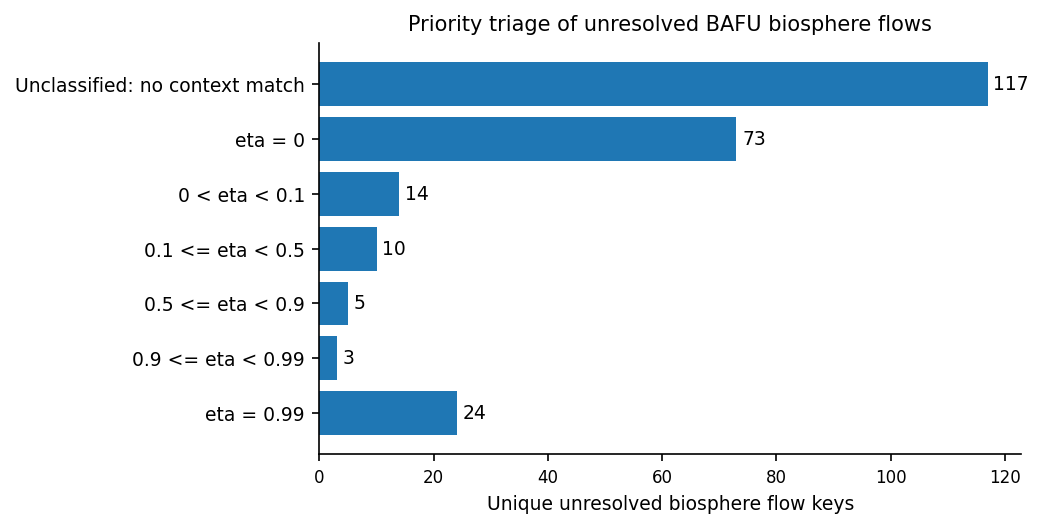

In [169]:
import matplotlib.pyplot as plt

plot_data = summary.copy()

plot_data["label"] = plot_data.apply(
    lambda r: (
        "Unclassified: no context match"
        if r["match_status"] == "not_found"
        else r["priority_class"]
    ),
    axis=1,
)

order = [
    "Unclassified: no context match",
    "eta = 0",
    "0 < eta < 0.1",
    "0.1 <= eta < 0.5",
    "0.5 <= eta < 0.9",
    "0.9 <= eta < 0.99",
    "eta = 0.99",
]

plot_data["label"] = pd.Categorical(
    plot_data["label"],
    categories=order,
    ordered=True,
)

plot_data = (
    plot_data
    .groupby("label", observed=True)["n_flows"]
    .sum()
    .reindex(order)
    .dropna()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 3.6))

ax.barh(plot_data["label"], plot_data["n_flows"])

for i, value in enumerate(plot_data["n_flows"]):
    ax.text(value + 1, i, f"{int(value)}", va="center")

ax.set_xlabel("Unique unresolved biosphere flow keys")
ax.set_ylabel("")
ax.set_title("Priority triage of unresolved BAFU biosphere flows")

ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("bafu_unlinked_priority_triage.pdf", bbox_inches="tight")
plt.savefig("bafu_unlinked_priority_triage.png", dpi=300, bbox_inches="tight")
plt.show()

In [170]:
# Illustrative examples: two context-matched unresolved flows per priority class.
# These are not additional matches. They are examples from the accepted context matches.

accepted = matched[
    matched["match_status"].eq("context_match")
].copy()

class_order = [
    "eta = 0",
    "0 < eta < 0.1",
    "0.1 <= eta < 0.5",
    "0.5 <= eta < 0.9",
    "0.9 <= eta < 0.99",
    "eta = 0.99",
]

accepted["priority_class"] = pd.Categorical(
    accepted["priority_class"],
    categories=class_order,
    ordered=True,
)

# Include witness columns if the priority file contains them.
witness_cols = [
    col for col in accepted.columns
    if "witness" in col.lower()
]

sample_cols = [
    "priority_class",
    "source_name",
    "source_categories",
    "source_unit",
    "flow_name",
    "compartment",
    "subcompartment",
    "reference_unit",
    ETA_COL,
    LOSS_COL,
] + witness_cols

priority_examples = (
    accepted
    .sort_values(
        ["priority_class", ETA_COL, LOSS_COL, "source_name"],
        ascending=[True, False, False, True],
    )
    .groupby("priority_class", observed=True, group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

display(priority_examples[sample_cols])

priority_examples[sample_cols].to_csv(
    "bafu_unlinked_priority_examples.csv",
    index=False,
)

,priority_class,source_name,source_categories,source_unit,flow_name,compartment,subcompartment,reference_unit,eta_0_99,loss_max_0_99,eta_0_95_witness,eta_0_99_witness
0,eta = 0,"Transformation, from forest, unspecified","(resources, unspecified)",square meter,"Transformation, from forest, unspecified",Resource,unspecified,m2,0.000000,0.006075,NaN,NaN
1,eta = 0,Carbon black,"(air,)",kilogram,Carbon black,Emission to air,unspecified,kg,0.000000,0.003612,NaN,NaN
2,eta = 0,N-octane,"(air,)",kilogram,N-octane,Emission to air,unspecified,kg,0.000000,0.001412,NaN,NaN
3,0 < eta < 0.1,"Water, well","(resources, unspecified)",cubic meter,"Water, well",Resource,unspecified,m3,0.097066,0.107066,Fireproofed flax tows from scutching {BE} | Hu...,Fireproofed flax tows from scutching {BE} | Hu...
4,0 < eta < 0.1,"Occupation, urban, discontinuously built","(resources, unspecified)",square meter-year,"Occupation, urban, discontinuously built",Resource,unspecified,m2*a,0.082026,0.091997,"Rammed earth wall, at building site {CH} | Urb...","Rammed earth wall, at building site {CH} | Urb..."
5,0 < eta < 0.1,Tributylstannane,"(water,)",kilogram,Tributylstannane,Emission to water,unspecified,kg,0.070588,0.080495,"Vinyl chloride, at plant {RER} | Ecotoxicity f...","Polypropylene, granulate, at plant {RER} | Fre..."
6,0.1 <= eta < 0.5,"Transformation, to annual crop, non-irrigated,...","(resources, unspecified)",square meter,"Transformation, to annual crop, non-irrigated,...",Resource,unspecified,m2,0.484999,0.494939,"Flax culture, flax straw {FR} | Land use | +","Flax culture, flax straw {FR} | Land use | +"
7,0.1 <= eta < 0.5,Sodium bromide,"(natural resource, in ground)",kilogram,Sodium bromide,Resource,in ground,kg,0.456003,0.465388,"Purified terephthalic acid, at plant {RER} | C...","Purified terephthalic acid, at plant {RER} | C..."
8,0.1 <= eta < 0.5,"Organic carbon, placed in landfill","(natural resource, in ground)",kilogram,"Organic carbon, placed in landfill",resources,in ground,kg,0.391320,0.396937,"Disposal, plastic plaster, 0% water, to constr...","Disposal, emulsion paint, 0% water, to constru..."
9,0.5 <= eta < 0.9,"Transformation, to industrial area","(resources, unspecified)",square meter,"Transformation, to industrial area",Resource,unspecified,m2,0.899019,0.909019,Gluing mill {CH} | Land use | +,Gluing mill {CH} | Land use | +


In [171]:
def group_bound(df, eta_col="eta_0_99", loss_col="loss_max_0_99", tau=0.99):
    df = df.dropna(subset=[eta_col, loss_col]).copy()

    if df.empty:
        return {
            "n_flows": 0,
            "lower_bound": None,
            "upper_bound": None,
        }

    lower = df[eta_col].max()

    total_loss = df[loss_col].sum()
    upper_candidates = (
        df[eta_col] + (total_loss - df[loss_col])
    )

    upper = min(tau, upper_candidates.min())

    return {
        "n_flows": len(df),
        "lower_bound": lower,
        "upper_bound": upper,
    }


matched_only = matched[
    matched["match_status"].eq("context_match")
].copy()

group_bounds_by_class = (
    matched_only
    .groupby("priority_class", observed=True)
    .apply(lambda g: pd.Series(group_bound(g)))
    .reset_index()
)

display(group_bounds_by_class)

/var/folders/ws/58lxc6157txbqhwp4lf352t40000gn/T/ipykernel_56231/2187010806.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(group_bound(g)))


,priority_class,n_flows,lower_bound,upper_bound
0,0 < eta < 0.1,14.0,0.097066,0.582437
1,0.1 <= eta < 0.5,10.0,0.484999,0.990000
2,0.5 <= eta < 0.9,5.0,0.899019,0.990000
3,0.9 <= eta < 0.99,3.0,0.988451,0.990000
4,eta = 0,73.0,0.000000,0.006381
5,eta = 0.99,24.0,0.990000,0.990000


Unmatched flows

In [172]:
# Audit unresolved biosphere flows that were not linked to the priority file.
# These are not low priority. They are unclassified by the conservative context join.

unmatched = matched[
    matched["match_status"].eq("not_found")
].copy()

# Recreate these fields if needed.
if "source_compartment" not in unmatched.columns:
    unmatched["source_compartment"] = unmatched["source_categories"].map(
        lambda x: category_part(x, 0)
    )

if "source_subcompartment" not in unmatched.columns:
    unmatched["source_subcompartment"] = unmatched["source_categories"].map(
        lambda x: category_part(x, 1)
    )

print(f"Unmatched unresolved biosphere flow keys: {len(unmatched):,}")

unmatched_context_summary = (
    unmatched
    .groupby(["source_compartment", "source_subcompartment"], dropna=False)
    .size()
    .reset_index(name="n_flows")
    .sort_values("n_flows", ascending=False)
    .reset_index(drop=True)
)

display(unmatched_context_summary)

Unmatched unresolved biosphere flow keys: 117


,source_compartment,source_subcompartment,n_flows
0,water,surface water,33
1,air,urban air close to ground,16
2,soil,agricultural,11
3,water,,10
4,air,,9
5,natural resource,in ground,7
6,air,non-urban air or from high stacks,5
7,economic,primary production factor,5
8,resources,unspecified,5
9,natural resource,land,3


In [173]:
# Show a small sample from each unmatched source context.

unmatched_sample = (
    unmatched
    .sort_values(["source_compartment", "source_subcompartment", "source_name"])
    .groupby(
        ["source_compartment", "source_subcompartment"],
        dropna=False,
        group_keys=False,
    )
    .head(3)
    .reset_index(drop=True)
)

display(
    unmatched_sample[
        [
            "source_compartment",
            "source_subcompartment",
            "source_name",
            "source_categories",
            "source_unit",
            "brightway_name",
            "brightway_categories",
            "brightway_unit",
        ]
    ]
)

unmatched_sample.to_csv(
    "bafu_unmatched_priority_sample.csv",
    index=False,
)

,source_compartment,source_subcompartment,source_name,source_categories,source_unit,brightway_name,brightway_categories,brightway_unit
0,air,,"('air', 'non-urban air or from high stacks')","(air,)",kilogram,"('air', 'non-urban air or from high stacks')","(air,)",kilogram
1,air,,"Ethane, chloro-","(air,)",kilogram,"Ethane, chloro-","(air,)",kilogram
2,air,,Ethene,"(air,)",kilogram,Ethene,"(air,)",kilogram
3,air,lower stratosphere + upper troposphere,Ethene,"(air, lower stratosphere + upper troposphere)",kilogram,Ethene,"(air, lower stratosphere + upper troposphere)",kilogram
4,air,lower stratosphere + upper troposphere,Hydrogen chloride,"(air, lower stratosphere + upper troposphere)",kilogram,Hydrogen chloride,"(air, lower stratosphere + upper troposphere)",kilogram
5,air,non-urban air or from high stacks,Ethene,"(air, non-urban air or from high stacks)",kilogram,Ethene,"(air, non-urban air or from high stacks)",kilogram
6,air,non-urban air or from high stacks,"Ethene, tetrachloro-","(air, non-urban air or from high stacks)",kilogram,"Ethene, tetrachloro-","(air, non-urban air or from high stacks)",kilogram
7,air,non-urban air or from high stacks,Hydrogen chloride,"(air, non-urban air or from high stacks)",kilogram,Hydrogen chloride,"(air, non-urban air or from high stacks)",kilogram
8,air,non-urban air or from high-stacks,Trifluralin,"(air, non-urban air or from high-stacks)",kilogram,Trifluralin,"(air, non-urban air or from high-stacks)",kilogram
9,air,urban air close to ground,"Acetylene, dichloro-","(air, urban air close to ground)",kilogram,"Acetylene, dichloro-","(air, urban air close to ground)",kilogram
